### Import all the necessary libraries

In [1]:
import tensorflow as tf
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from bs4 import BeautifulSoup
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer ,WordNetLemmatizer
import string



I0000 00:00:1785423528.135134   45991 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785423528.166241   45991 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1785423528.906129   45991 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/rishabh/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/rishabh/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/rishabh/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

### Loading the dataset 

In [3]:
data = pd.read_csv("../dataset/IMDB Dataset.csv")

In [4]:
### Text preprocessing

punctuations = string.punctuation
lm = WordNetLemmatizer()

# Step 1: Define NEGATION_WORDS first
NEGATION_WORDS = {
    "not", "no", "never", "nor", "neither", "nobody", "nothing", "nowhere",
    "n't", "cant", "cannot", "wont", "dont", "doesnt", "didnt",
    "isnt", "wasnt", "werent", "havent", "hasnt", "hadnt",
    "shouldnt", "wouldnt", "couldnt", "mightnt", "mustnt"
}

# Step 2: Build filtered stopwords (keeping negations)
stopwords_filtered = set(
    w for w in nltk.corpus.stopwords.words('english')
    if w not in NEGATION_WORDS
)

# Step 3: Define negate_sequence
def negate_sequence(text, window=4):
    words = text.split()
    result = []
    negation_counter = 0
    for word in words:
        if word.lower() in NEGATION_WORDS:
            negation_counter = window
            result.append(word)
            continue
        if negation_counter > 0:
            result.append("NOT_" + word)
            negation_counter -= 1
        else:
            result.append(word)
    return " ".join(result)

# Step 4: Define clean_text
def clean_text(text):
    only_text = BeautifulSoup(text, "html.parser").get_text()
    text = "".join([char.lower() for char in only_text if char not in punctuations])
    tokens = word_tokenize(text)
    filtered = " ".join([lm.lemmatize(token) for token in tokens
                         if token not in stopwords_filtered])
    return negate_sequence(filtered)

# Step 5: NOW apply to data
X = data['review'].apply(lambda x: clean_text(x))
Y = data['sentiment'].apply(lambda x: 1 if x == 'positive' else 0)

# Step 6: Sanity check BEFORE proceeding
print(clean_text("This movie is worth it"))
# → "movie worth"

print(clean_text("This movie is not worth it"))
# → "movie not NOT_worth"  ("this"/"is"/"it" are stopwords; "not" survives and tags "worth")

movie worth
movie not NOT_worth


### Train test split

Split *before* tokenizing/training Word2Vec so the embeddings and vocabulary are
built only from training data — otherwise the model has effectively seen the
test set's vocabulary and co-occurrence statistics during "unsupervised"
pretraining, which leaks test information into the model.

In [5]:
from sklearn.model_selection import train_test_split

## train (70%) / validation (15%) / test (15%)
## validation is used for early stopping / model selection; test is only
## touched once, at the very end, for the final reported metrics
X_train, X_temp, Y_train, Y_temp = train_test_split(
    np.array(X.to_list()), np.array(Y.to_list()), test_size=0.3, random_state=42
)
X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp, Y_temp, test_size=0.5, random_state=42
)

### Tokenizing Sentence 

In [6]:
X_train

array(['much love train couldnt NOT_stomach NOT_movie NOT_premise NOT_one could steal locomotive drive arkansas chicago without hitting another train along way right impossible plot line hit board imagine two disgruntled nasa employee stealing crawler tote shuttle fro driving new york get ideahaving said nice try wilford brimely quaker oat best levon helm turn good performance dimwitted wellmeaning sidekick bob balaban suitably wormy corporate guy little guy take goliath story get another airing',
       'good ppv like wrestlemania xx 14 year later wwe crammed many match match useless im not NOT_going NOT_go NOT_every NOT_match card would take forever dohowever major highlight included huge pop demolition winning tag team belt haku andre giant first ever mixed tag match featuring randy savage sensational queen sherri v dusty rhodes late sapphire first ever clash ultimate warrior hulk hogansome match complete waste time like bolshevik v hart foundation 40 second long koko b ware v rick 

In [7]:
tokenized = [word_tokenize(sentence) for sentence in X_train]

In [8]:
tokenized

[['much',
  'love',
  'train',
  'couldnt',
  'NOT_stomach',
  'NOT_movie',
  'NOT_premise',
  'NOT_one',
  'could',
  'steal',
  'locomotive',
  'drive',
  'arkansas',
  'chicago',
  'without',
  'hitting',
  'another',
  'train',
  'along',
  'way',
  'right',
  'impossible',
  'plot',
  'line',
  'hit',
  'board',
  'imagine',
  'two',
  'disgruntled',
  'nasa',
  'employee',
  'stealing',
  'crawler',
  'tote',
  'shuttle',
  'fro',
  'driving',
  'new',
  'york',
  'get',
  'ideahaving',
  'said',
  'nice',
  'try',
  'wilford',
  'brimely',
  'quaker',
  'oat',
  'best',
  'levon',
  'helm',
  'turn',
  'good',
  'performance',
  'dimwitted',
  'wellmeaning',
  'sidekick',
  'bob',
  'balaban',
  'suitably',
  'wormy',
  'corporate',
  'guy',
  'little',
  'guy',
  'take',
  'goliath',
  'story',
  'get',
  'another',
  'airing'],
 ['good',
  'ppv',
  'like',
  'wrestlemania',
  'xx',
  '14',
  'year',
  'later',
  'wwe',
  'crammed',
  'many',
  'match',
  'match',
  'useless',


In [9]:
X_train[0]

np.str_('much love train couldnt NOT_stomach NOT_movie NOT_premise NOT_one could steal locomotive drive arkansas chicago without hitting another train along way right impossible plot line hit board imagine two disgruntled nasa employee stealing crawler tote shuttle fro driving new york get ideahaving said nice try wilford brimely quaker oat best levon helm turn good performance dimwitted wellmeaning sidekick bob balaban suitably wormy corporate guy little guy take goliath story get another airing')

In [10]:
tokenized[0]

['much',
 'love',
 'train',
 'couldnt',
 'NOT_stomach',
 'NOT_movie',
 'NOT_premise',
 'NOT_one',
 'could',
 'steal',
 'locomotive',
 'drive',
 'arkansas',
 'chicago',
 'without',
 'hitting',
 'another',
 'train',
 'along',
 'way',
 'right',
 'impossible',
 'plot',
 'line',
 'hit',
 'board',
 'imagine',
 'two',
 'disgruntled',
 'nasa',
 'employee',
 'stealing',
 'crawler',
 'tote',
 'shuttle',
 'fro',
 'driving',
 'new',
 'york',
 'get',
 'ideahaving',
 'said',
 'nice',
 'try',
 'wilford',
 'brimely',
 'quaker',
 'oat',
 'best',
 'levon',
 'helm',
 'turn',
 'good',
 'performance',
 'dimwitted',
 'wellmeaning',
 'sidekick',
 'bob',
 'balaban',
 'suitably',
 'wormy',
 'corporate',
 'guy',
 'little',
 'guy',
 'take',
 'goliath',
 'story',
 'get',
 'another',
 'airing']

### Word2Vec

In [11]:
from gensim.models import Word2Vec
W2V_model = Word2Vec(
    sentences = tokenized,
    vector_size= 200, 
    window =5,
    min_count=2,
    sg=0,
    epochs = 8
)

In [12]:
print("NOT_worth" in W2V_model.wv)  # Should be True
print(W2V_model.wv.most_similar("NOT_worth"))  # Should cluster with negative words

True
[('NOT_wasting', 0.7532298564910889), ('NOT_spending', 0.7141110301017761), ('NOT_total', 0.6939448714256287), ('NOT_youre', 0.6859405040740967), ('NOT_riff', 0.6823633313179016), ('NOT_watching', 0.6789435744285583), ('NOT_renting', 0.6782627701759338), ('NOT_timeits', 0.6758310198783875), ('NOT_painful', 0.6743626594543457), ('NOT_recommended', 0.6719920039176941)]


In [13]:
W2V_model.wv['good'].shape

(200,)

In [14]:
W2V_model.wv.most_similar(5)

[('timethe', 0.5082278847694397),
 ('twice', 0.46696388721466064),
 ('timesi', 0.45801231265068054),
 ('time310', 0.44589561223983765),
 ('occasion', 0.4439879357814789),
 ('week', 0.4433935284614563),
 ('timei', 0.443325936794281),
 ('timebut', 0.43908560276031494),
 ('100x', 0.4298691153526306),
 ('hour', 0.4204804003238678)]

### Text vectorization 

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM ,Embedding , Bidirectional, TextVectorization



In [16]:
vocab_size =20000
max_len= 200
vectorized_layer = TextVectorization(
    max_tokens = vocab_size,
    output_mode = 'int',
    output_sequence_length = max_len,
    

)

I0000 00:00:1785423591.530692   45991 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21878 MB memory:  -> device: 0, name: NVIDIA RTX A5000, pci bus id: 0000:01:00.0, compute capability: 8.6


In [17]:
vectorized_layer.adapt(X_train)

In [18]:
vocab = np.array(vectorized_layer.get_vocabulary())

In [19]:
vocab[:10]

array(['', '[UNK]', 'movie', 'film', 'not', 'one', 'like', 'time',
       'character', 'no'], dtype='<U19')

### BUILDING EMBEDDING

In [20]:
W2V_model.vector_size

200

In [21]:
vocab = vectorized_layer.get_vocabulary()
emb_dim = W2V_model.vector_size
embedding_matrix = np.zeros((len(vocab), emb_dim)) ###  20000 X 200 matrix

for i, word in enumerate(vocab):
    if word in W2V_model.wv:
        embedding_matrix[i] = W2V_model.wv[word]


In [22]:
embedding_matrix

array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [-0.15275744,  1.230317  ,  0.18511245, ...,  0.59421593,
         0.55159253,  0.18724513],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ]], shape=(20000, 200))

  ### Step-2: Initialize Keras Embedding with these weights

In [23]:
embedding_layer = Embedding(
    input_dim=len(vocab),
    output_dim=emb_dim,
    weights= [embedding_matrix],
    trainable= True   # fine-tune the pretrained Word2Vec weights during training
)

W0000 00:00:1785423593.401349   46756 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1785423593.402386   46755 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1785423593.404032   46757 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1785423593.405327   46752 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1785423593.407278   46762 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1785423593.408946   46763 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1785423593.410244   46751 gpu_kernel_to_blob_pass.cc:190] Failed to co

### Building bidirectional LSTM Model 

In [24]:
model = Sequential()

model.add(tf.keras.Input(shape=(1,), dtype=tf.string))

model.add(vectorized_layer)
model.add(embedding_layer)
model.add(tf.keras.layers.SpatialDropout1D(0.3))
model.add(Bidirectional(LSTM(100, dropout = 0.3,activation='tanh')))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1,activation='sigmoid'))
model.summary()

W0000 00:00:1785423593.703906   45991 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 200)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 200, 200)       │     4,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 200, 200)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 200)            │       240,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,253,729 (16.23 MB)

 Trainable params: 4,253,729 (16.23 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
model.compile(optimizer='Adam',loss='binary_crossentropy',metrics=['accuracy'])

In [26]:
print(type(X_train))
print(X_train.dtype if hasattr(X_train, 'dtype') else "No dtype")

print(type(Y_train))
print(Y_train.dtype if hasattr(Y_train, 'dtype') else "No dtype")

<class 'numpy.ndarray'>
<U9448
<class 'numpy.ndarray'>
int64


In [27]:
X_train_tf = tf.constant(X_train, dtype=tf.string)
X_val_tf = tf.constant(X_val, dtype=tf.string)
X_test_tf = tf.constant(X_test, dtype=tf.string)

In [28]:
print(X_train.shape)
print(X_train.dtype)
print(type(X_train[0]))
print(X_train[0][:100])

print(Y_train.shape)
print(Y_train.dtype)

(35000,)
<U9448
<class 'numpy.str_'>
much love train couldnt NOT_stomach NOT_movie NOT_premise NOT_one could steal locomotive drive arkan
(35000,)
int64


In [29]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history = model.fit(X_train_tf,Y_train,validation_data=(X_val_tf,Y_val),batch_size=32,epochs=20,
                    callbacks=[early_stop]
                    )

Epoch 1/20


W0000 00:00:1785423595.623440   46920 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1785423595.624470   46916 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1785423595.625981   46923 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1785423595.627526   46921 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1785423595.628551   46915 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1785423595.629821   46930 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1785423595.630857   46929 gpu_kernel_to_blob_pass.cc:190] Failed to co

W0000 00:00:1785423596.080425   46959 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1785423596.082312   46955 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1785423596.083344   46958 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1785423596.084331   46956 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1785423596.085879   46960 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1785423596.087235   46952 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1785423596.088393   46961 gpu_kernel_to_blob_pass.cc:190] Failed to co

W0000 00:00:1785423596.361857   46722 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
I0000 00:00:1785423596.385107   46722 cuda_dnn.cc:461] Loaded cuDNN version 92000
W0000 00:00:1785423596.449582   46722 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1785423596.485751   46722 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1785423596.518240   46722 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1785423596.543936   46722 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.


   1/1094 ━━━━━━━━━━━━━━━━━━━━ 36:20 2s/step - accuracy: 0.5625 - loss: 0.7171

...

1081/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9531 - loss: 0.1390

1085/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9531 - loss: 0.1390

1089/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9531 - loss: 0.1391

1093/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9531 - loss: 0.1391

1094/1094 ━━━━━━━━━━━━━━━━━━━━ 17s 16ms/step - accuracy: 0.9494 - loss: 0.1465 - val_accuracy: 0.8915 - val_loss: 0.3310


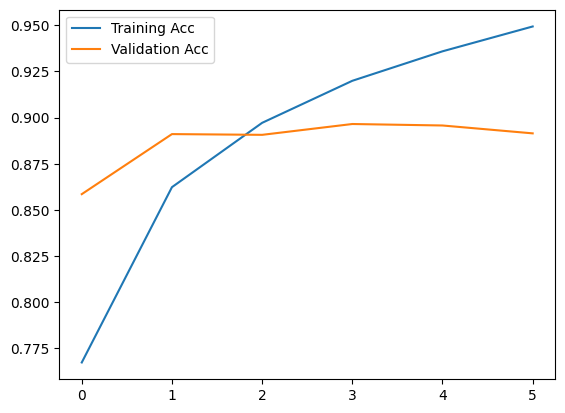

In [30]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'],label='Training Acc')
plt.plot(history.history['val_accuracy'],label='Validation Acc')
plt.legend()
plt.show()

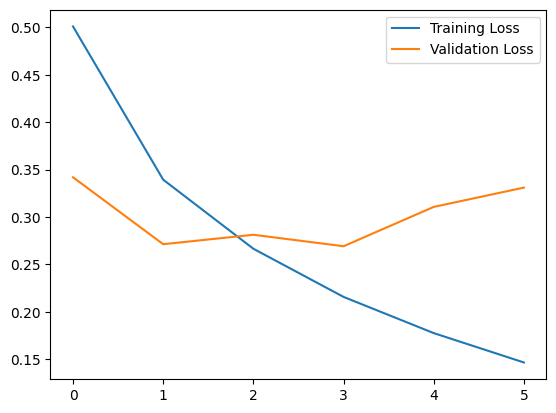

In [31]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.legend()
plt.show()

In [32]:
print(clean_text("This movie is worth it"))
print(clean_text("This movie is not worth it"))

movie worth
movie not NOT_worth


## Prediction on Random Text 

In [33]:
test_text = "Not worth it "

pred = model.predict(
    tf.constant([clean_text(test_text)], dtype=tf.string)
)



if pred[0][0] > 0.5:
    print("Positive Sentiment")
    print("Score:", pred[0][0])
else:
    print("Negative Sentiment")
    print("Score:", pred[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


Negative Sentiment
Score: 0.080001


In [34]:
test_text_1 = "worth it   for adults if u are student then not too worth  "

pred = model.predict(
    tf.constant([clean_text(test_text_1)], dtype=tf.string)
)



if pred[0][0] > 0.5:
    print("Positive Sentiment")
    print("Score:", pred[0][0])
else:
    print("Negative Sentiment")
    print("Score:", pred[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


Positive Sentiment
Score: 0.61718374


In [35]:
y_pred = model.predict(X_test_tf)
y_pred_binary = np.where(y_pred > 0.5, 1, 0)
y_pred_binary

  1/235 ━━━━━━━━━━━━━━━━━━━━ 28s 122ms/step

 11/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step   

 21/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

 31/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

 41/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

...

207/235 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

218/235 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

229/235 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


array([[0],
       [0],
       [0],
       ...,
       [0],
       [1],
       [0]], shape=(7500, 1))

In [36]:
y_pred_binary.shape

(7500, 1)

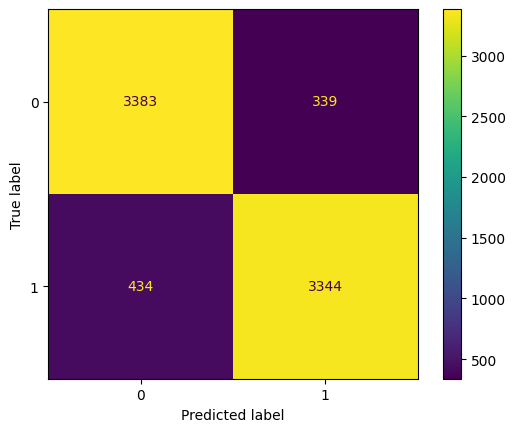

In [37]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix(Y_test,y_pred_binary))
disp.plot()

In [38]:
print(classification_report(Y_test, y_pred_binary))

              precision    recall  f1-score   support

           0       0.89      0.91      0.90      3722
           1       0.91      0.89      0.90      3778

    accuracy                           0.90      7500
   macro avg       0.90      0.90      0.90      7500
weighted avg       0.90      0.90      0.90      7500



In [39]:
model.save("../models/sentiment_classifier_2.keras")